## Panning an oscillator's output

In [1]:
import numpy as np
from IPython.display import Audio, display
from matplotlib import pyplot as plt

from constants import DEFAULT_SAMPLE_RATE
from engine import Chain, ModulatedPanner, Panner, SineOscillator
from utils import save_wave

# Set up plotting style
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["font.size"] = 10

## Creating a static panner

And varying the pan position within a loop

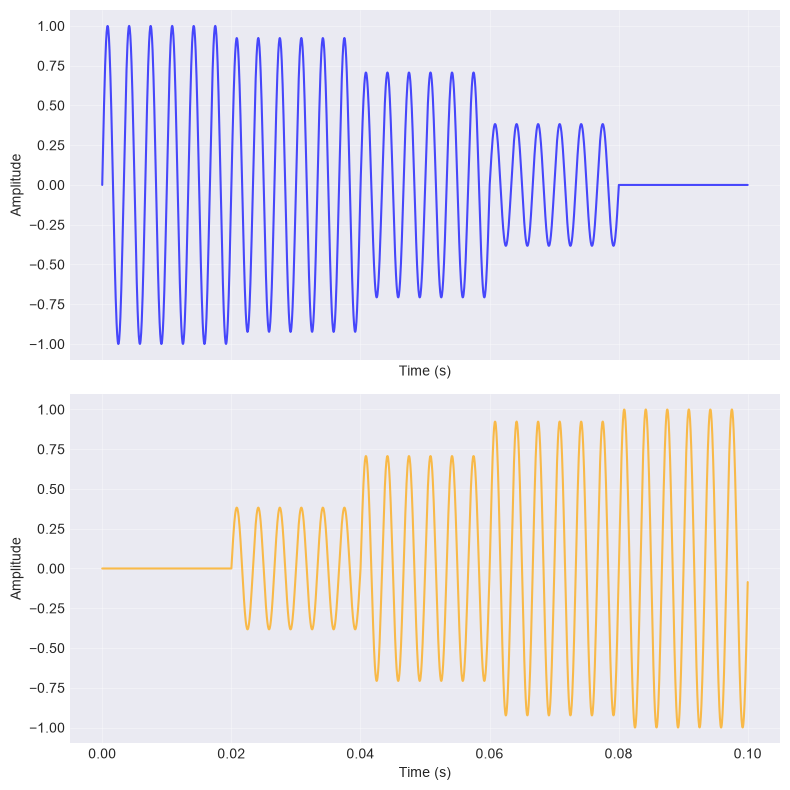

In [2]:
sr = DEFAULT_SAMPLE_RATE / 10
t = 0.1
num_samples = int(sr * t)
samples = SineOscillator(60, amplitude=1, sample_rate=sr).get_samples(num_samples)
t = np.linspace(0, t, 5 * num_samples)

left, right = [], []
for position in [-1.0, -0.5, 0.0, 0.5, 1.0]:
    left_samples, right_samples = Panner(position=position)(samples)

    # Append samples to the lists
    left.extend(left_samples)
    right.extend(right_samples)

_, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
ax1.plot(t, left, label="Left", color="blue", alpha=0.7)
ax2.plot(t, right, label="Right", color="orange", alpha=0.7)
ax1.set_xlabel("Time (s)")
ax2.set_xlabel("Time (s)")
ax1.set_ylabel("Amplitude")
ax2.set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

## Modulated panning

This example demonstrates modulated stereo panning using an LFO (Low Frequency Oscillator).
The pan position oscillates between left and right at 4 Hz, creating an auto-panning effect.

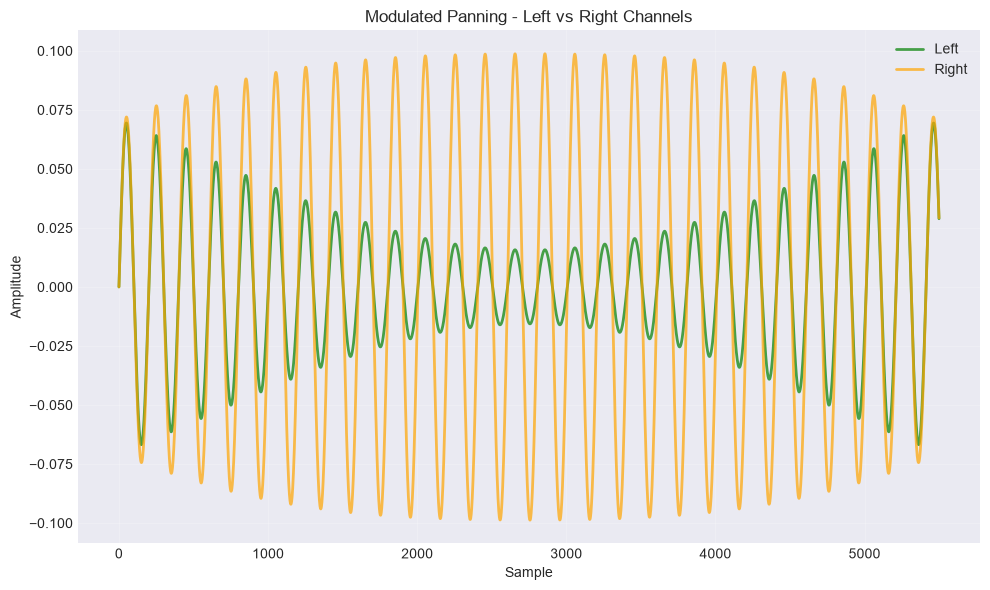

In [3]:
# Create a 220Hz sine wave with auto-panning at 4Hz
# NOTE: The LFO needs amplitude=1.0 and gain_db=None so wave_range is not scaled
gen = Chain(
    SineOscillator(220),
    ModulatedPanner(SineOscillator(4, wave_range=(-0.8, 0.8), amplitude=1.0)),
)

plt.figure(figsize=(10, 6))
wav = gen.get_samples(5500)
left, right = np.array(wav).T

plt.plot(left, label="Left", color="green", alpha=0.7, linewidth=2)
plt.plot(right, label="Right", color="orange", alpha=0.7, linewidth=2)
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Modulated Panning - Left vs Right Channels")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
save_wave(
    left, right, filename="oscillators_v7_panning.wav", sample_rate=DEFAULT_SAMPLE_RATE
)
display(Audio("oscillators_v7_panning.wav"))